<a href="https://colab.research.google.com/github/crwendler7-lab/Data-Science-II/blob/main/TrabajoCDII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo Modelos de Machine Learning: Impacto de la IA en los estudiantes**

Carga del las librerias

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Carga del Dataset

In [4]:
url='https://raw.githubusercontent.com/crwendler7-lab/Data-Science-II/refs/heads/main/ai_student_impact_dataset%20(1).csv'
df=pd.read_csv(url)
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


Visualización de las dimenciones del dataset

In [5]:
df.shape

(50000, 16)

Visualizaciónde la información del dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [7]:
print(df.isnull().sum())

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


In [8]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000



Renombrar las columnas

In [9]:
df=df.rename(columns={
    "Student_ID":"ID_estudiante",
    "Major_Category":"Categoria_Principal",
    "Year_of_Study":"Año_de_estudio",
    "Pre_Semester_GPA":"Promedio_de_calificaciones",
    "Weekly_GenAI_Hours":"Horas_semanales_con_IA",
    "Primary_Use_Case":"Caso_de_uso_primario",
    "Prompt_Engineering_Skill":"Habilidad_prompt",
    "Tool_Diversity":"diversidad_de_herramientas",
    "Paid_Subscription":"Suscripcion",
    "Traditional_Study_Hours":"Horas_de_estudio_sin_IA",
    "Perceived_AI_Dependency":"Dependencia_de_IA",
    "Institutional_Policy":"Politica_institucional",
    "Anxiety_Level_During_Exams":"Ansiedad",
    "Post_Semester_GPA":"Puntuacion_post_semestre",
    "Skill_Retention_Score":"Nivel_de_retencion",
    "Burnout_Risk_Level":"Nivel_Burnout"
})
df.head()

,ID_estudiante,Categoria_Principal,Año_de_estudio,Promedio_de_calificaciones,Horas_semanales_con_IA,Caso_de_uso_primario,Habilidad_prompt,diversidad_de_herramientas,Suscripcion,Horas_de_estudio_sin_IA,Dependencia_de_IA,Politica_institucional,Ansiedad,Puntuacion_post_semestre,Nivel_de_retencion,Nivel_Burnout
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


Identificar valores nulos

In [10]:
df.isnull().sum()

,0
ID_estudiante,0
Categoria_Principal,0
Año_de_estudio,0
Promedio_de_calificaciones,0
Horas_semanales_con_IA,0
Caso_de_uso_primario,0
Habilidad_prompt,0
diversidad_de_herramientas,0
Suscripcion,0
Horas_de_estudio_sin_IA,0


0 como valor nulo

In [11]:
zero=df==0
zero.sum()

,0
ID_estudiante,0
Categoria_Principal,0
Año_de_estudio,0
Promedio_de_calificaciones,0
Horas_semanales_con_IA,28
Caso_de_uso_primario,0
Habilidad_prompt,0
diversidad_de_herramientas,0
Suscripcion,28846
Horas_de_estudio_sin_IA,0


Indentificación de duplicados

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Cambio_de_calificacion']=df['Puntuacion_post_semestre']-df['Promedio_de_calificaciones']
df.head()

,ID_estudiante,Categoria_Principal,Año_de_estudio,Promedio_de_calificaciones,Horas_semanales_con_IA,Caso_de_uso_primario,Habilidad_prompt,diversidad_de_herramientas,Suscripcion,Horas_de_estudio_sin_IA,Dependencia_de_IA,Politica_institucional,Ansiedad,Puntuacion_post_semestre,Nivel_de_retencion,Nivel_Burnout,Cambio_de_calificacion
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163


**Gráfico de Dispersión (Scatter Plot)**

<Figure size 1000x600 with 0 Axes>

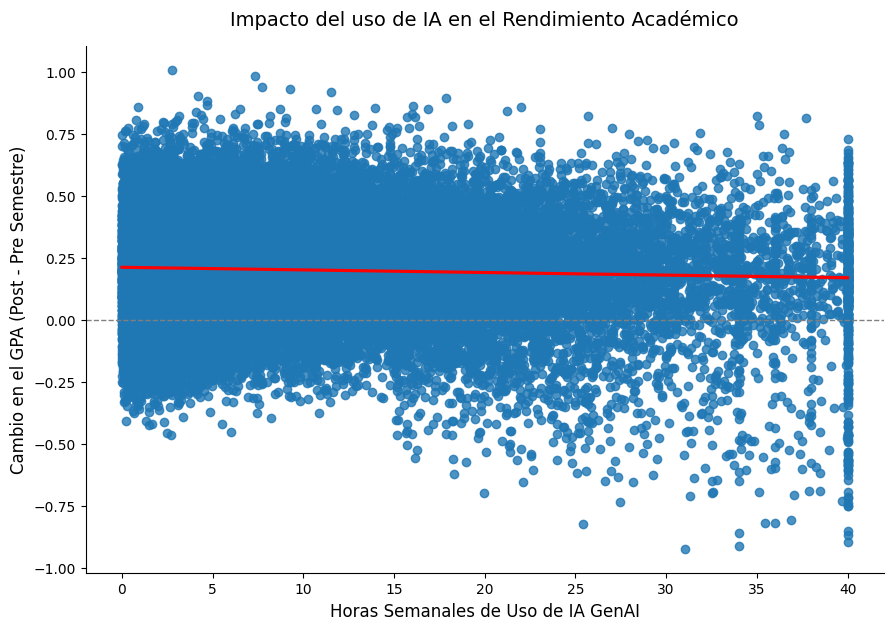

In [14]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df,
    x='Horas_semanales_con_IA',
    y='Cambio_de_calificacion',
    height=6,
    aspect=1.5,
    line_kws={'color': 'red'}
)
plt.title('Impacto del uso de IA en el Rendimiento Académico', fontsize=14, pad=15)
plt.xlabel('Horas Semanales de Uso de IA GenAI', fontsize=12)
plt.ylabel('Cambio en el GPA (Post - Pre Semestre)', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.show()

**Gráfico de Cajas (Boxplot)**

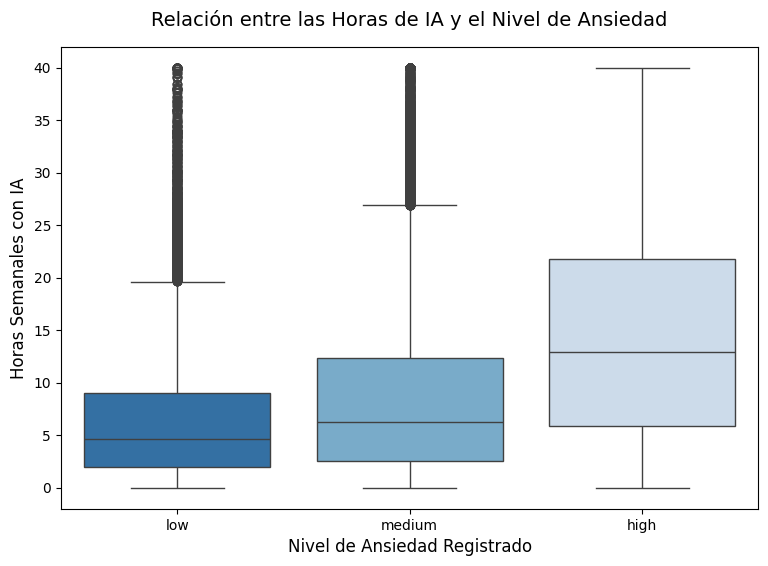

In [15]:
plt.figure(figsize=(9, 6))
orden_ansiedad = ['low', 'medium', 'high']

bins = [0, 3, 7, 10]
labels = ['low', 'medium', 'high']
df['Nivel_de_Ansiedad_Categorico'] = pd.cut(df['Ansiedad'], bins=bins, labels=labels, right=True, include_lowest=True)

sns.boxplot(
    data=df,
    x='Nivel_de_Ansiedad_Categorico',
    y='Horas_semanales_con_IA',
    order=orden_ansiedad,
    palette='Blues_r',
    hue='Nivel_de_Ansiedad_Categorico',
    legend=False
)
plt.title('Relación entre las Horas de IA y el Nivel de Ansiedad', fontsize=14, pad=15)
plt.xlabel('Nivel de Ansiedad Registrado', fontsize=12)
plt.ylabel('Horas Semanales con IA', fontsize=12)

plt.show()

**Gráfico de Barras de Promedios (Bar Chart)**

/tmp/ipykernel_1022/1105188537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


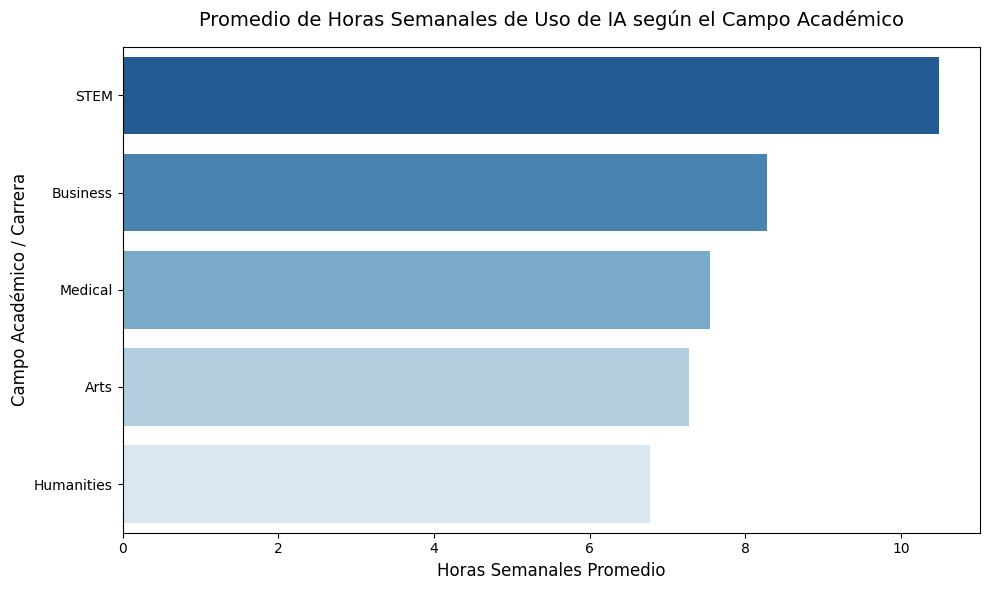

In [16]:
plt.figure(figsize=(10, 6))
orden_carreras = df.groupby('Categoria_Principal')['Horas_semanales_con_IA'].mean().sort_values(ascending=False).index
sns.barplot(
    data=df,
    y='Categoria_Principal',
    x='Horas_semanales_con_IA',
    order=orden_carreras,
    palette='Blues_r',
    errorbar=None
)
plt.title('Promedio de Horas Semanales de Uso de IA según el Campo Académico', fontsize=14, pad=15)
plt.xlabel('Horas Semanales Promedio', fontsize=12)
plt.ylabel('Campo Académico / Carrera', fontsize=12)
plt.tight_layout()
plt.show()

Carga del las librerias

In [27]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [18]:
n_samples = len(df)
df["Puntuacion_post_semestre"] = df["Promedio_de_calificaciones"] + np.random.uniform(-0.3, 0.4, n_samples)

df.head()

,ID_estudiante,Categoria_Principal,Año_de_estudio,Promedio_de_calificaciones,Horas_semanales_con_IA,Caso_de_uso_primario,Habilidad_prompt,diversidad_de_herramientas,Suscripcion,Horas_de_estudio_sin_IA,Dependencia_de_IA,Politica_institucional,Ansiedad,Puntuacion_post_semestre,Nivel_de_retencion,Nivel_Burnout,Cambio_de_calificacion,Nivel_de_Ansiedad_Categorico
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.533848,86.44,High,-0.025,medium
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,4.014500,69.39,Low,-0.125,high
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.702553,73.93,Medium,0.101,high
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,3.959758,63.58,Medium,0.211,low
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.736462,100.00,Medium,0.163,medium


In [19]:
df['Mejoro_Nota'] = (df['Puntuacion_post_semestre'] > df['Promedio_de_calificaciones']).astype(int)


In [20]:
features = ['Categoria_Principal', 'Año_de_estudio', 'Horas_semanales_con_IA',
            'Habilidad_prompt', 'diversidad_de_herramientas', 'Horas_de_estudio_sin_IA',
            'Dependencia_de_IA', 'Politica_institucional', 'Ansiedad']

X = df[features]
y = df['Mejoro_Nota']

In [21]:
num_features = ['Año_de_estudio', 'Horas_semanales_con_IA', 'diversidad_de_herramientas', 'Horas_de_estudio_sin_IA']
cat_features = ['Categoria_Principal', 'Habilidad_prompt', 'Dependencia_de_IA', 'Politica_institucional', 'Ansiedad']

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

Dividir el dataset

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras\n")

Datos de entrenamiento: 40000 muestras
Datos de prueba: 10000 muestras



In [24]:
print("--- Iniciando la optimización con GridSearch ---")

--- Iniciando la optimización con GridSearch ---


MODELO 1: Árbol de Decisión

In [29]:
pipeline_tree = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', DecisionTreeClassifier(random_state=42))])

param_grid_tree = {
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_tree = GridSearchCV(pipeline_tree, param_grid_tree, cv=5, scoring='roc_auc', n_jobs=-1)
grid_tree.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Horas_semanales_con_IA',
                                                                          'diversidad_de_herramientas',
                                                                          'Horas_de_estudio_sin_IA']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Categoria_Principal',
                                                                          'Año_de_estudio',
                                                                          'Habilidad_prompt',
                                                                          'Dependencia_de_IA',
                                                                          'Politica_institucional',
                                                                          'Ansiedad'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [3, 5, 7, 10],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

MODELO 2: Regresión Logística

In [30]:
pipeline_logreg = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

param_grid_logreg = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2']
}

grid_logreg = GridSearchCV(pipeline_logreg, param_grid_logreg, cv=5, scoring='roc_auc', n_jobs=-1)
grid_logreg.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Horas_semanales_con_IA',
                                                                          'diversidad_de_herramientas',
                                                                          'Horas_de_estudio_sin_IA']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Categoria_Principal',
                                                                          'Año_de_estudio',
                                                                          'Habilidad_prompt',
                                                                          'Dependencia_de_IA',
                                                                          'Politica_institucional',
                                                                          'Ansiedad'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l2']},
             scoring='roc_auc')

Selección de modelo

In [31]:
# Evaluamos Árbol de Decisión
y_pred_tree = grid_tree.predict(X_test)
y_proba_tree = grid_tree.predict_proba(X_test)[:, 1]
auc_tree = roc_auc_score(y_test, y_proba_tree)

# Evaluamos Regresión Logística
y_pred_logreg = grid_logreg.predict(X_test)
y_proba_logreg = grid_logreg.predict_proba(X_test)[:, 1]
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

print("================ METRICAS FINALES ================")
print(f"Árbol de Decisión -> Mejor combinación: {grid_tree.best_params_}")
print(f"Árbol de Decisión -> ROC-AUC en Test: {auc_tree:.4f}")
print(f"Árbol de Decisión -> Accuracy en Test: {accuracy_score(y_test, y_pred_tree):.4f}\n")

print(f"Regresión Logística -> Mejor combinación: {grid_logreg.best_params_}")
print(f"Regresión Logística -> ROC-AUC en Test: {auc_logreg:.4f}")
print(f"Regresión Logística -> Accuracy en Test: {accuracy_score(y_test, y_pred_logreg):.4f}")
print("==================================================")

# Elección automática del mejor modelo basado en la métrica ROC-AUC
if auc_tree > auc_logreg:
    print("\nEL MEJOR MODELO SELECCIONADO ES: ÁRBOL DE DECISIÓN")
    print(classification_report(y_test, y_pred_tree))
else:
    print("\nEL MEJOR MODELO SELECCIONADO ES: REGRESIÓN LOGÍSTICA")
    print(classification_report(y_test, y_pred_logreg))

================ METRICAS FINALES ================
Árbol de Decisión -> Mejor combinación: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Árbol de Decisión -> ROC-AUC en Test: 0.5011
Árbol de Decisión -> Accuracy en Test: 0.5717

Regresión Logística -> Mejor combinación: {'classifier__C': 10, 'classifier__penalty': 'l2'}
Regresión Logística -> ROC-AUC en Test: 0.5094
Regresión Logística -> Accuracy en Test: 0.5727

EL MEJOR MODELO SELECCIONADO ES: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

           0       0.75      0.00      0.00      4275
           1       0.57      1.00      0.73      5725

    accuracy                           0.57     10000
   macro avg       0.66      0.50      0.36     10000
weighted avg       0.65      0.57      0.42     10000

